# Dimensionality Reduction with PCA

**Dataset:** Wine Quality dataset with 12 features + 1 target. The quality score is on a scale from 3 - 9.
    The dataset was selected due to having only numeric columns which is eesential for Principal Component Analysis(PCA).

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [41]:
df = pd.read_csv("wine_quality_dataset.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [42]:
df = df.drop(columns=["Id"])
x = df.drop(columns=["quality"])
y = df["quality"]


In [43]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Scaling data

In [29]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Mean per feature:", np.round(x_scaled.mean(axis=0)[:5],3))
print("Standard deviation per feature:", np.round(x_scaled.std(axis=0)[:5],3))

Mean per feature: [-0.  0.  0.  0.  0.]
Standard deviation per feature: [1. 1. 1. 1. 1.]


    The "Id" column was useless and hence dropped. No missing data was found.
    11 features were standardised (0 mean, 1 standard deviation).
    Since all the features were numeric, there was no one-hot encoding needed.

### Fitting PCA

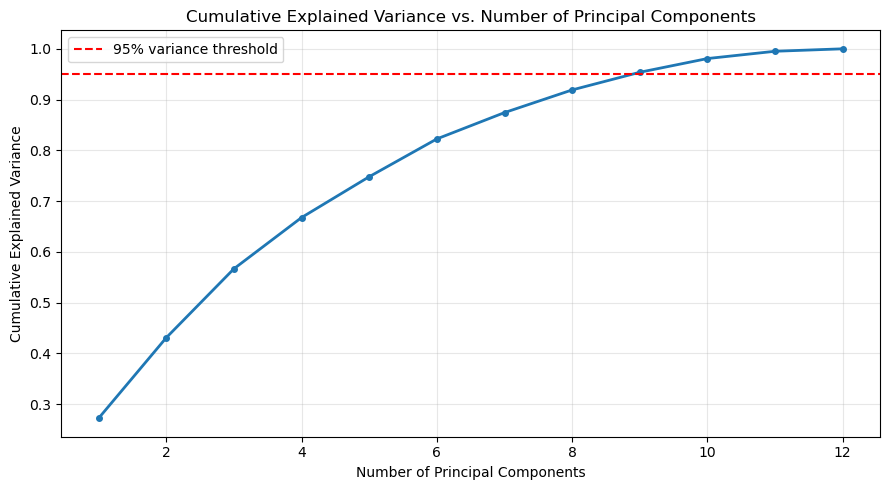

In [30]:
pca = PCA()
pca.fit(x_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', linewidth=2, markersize=4)
ax.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Explained Variance vs. Number of Principal Components")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_variance.png", dpi=150)
plt.show()

### Number of components for 95% variance

In [44]:
n_comp_95 = np.argmax(cum_var >= 0.95)+1
print(f"Number of components needed to retain >= 95% variance: {n_comp_95}")
print(f"Cumulative variance at that point: {cum_var[n_comp_95-1]}")
print(f"Original dimensions: {x.shape[1]} -> Reduced dimentions: {n_comp_95}")

Number of components needed to retain >= 95% variance: 9
Cumulative variance at that point: 0.9537880952694247
Original dimensions: 11 -> Reduced dimentions: 9


    PCA was fit on 11 features and plotted Cumulative explained variance. It was found that 9 components are needed to retain 95.3% of the total variance - only reduction of 2 dimensions. 

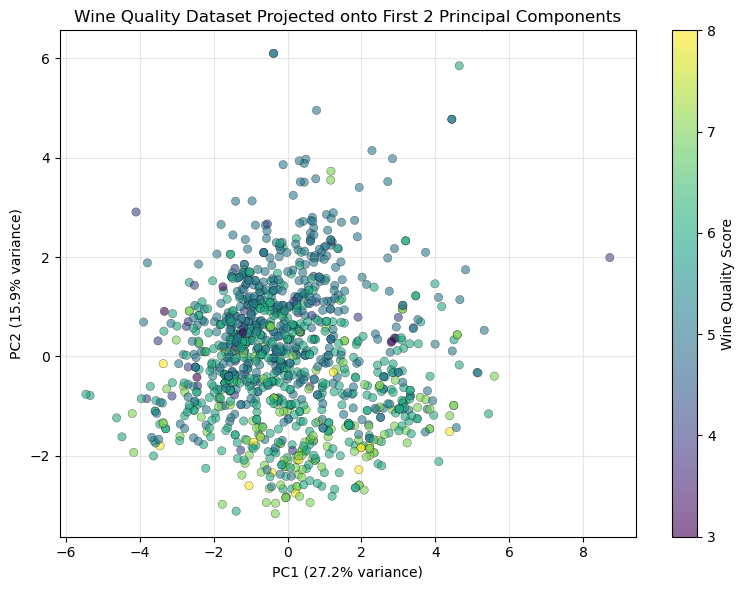

In [51]:
pca_2D = PCA(n_components=2)
x_pca_2d = pca_2D.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(x_pca_2d[:,0], x_pca_2d[:,1], c=y, cmap='viridis', alpha=0.6, edgecolors='k',linewidths=0.3)
plt.xlabel(f"PC1 ({pca_2D.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2D.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Wine Quality Dataset Projected onto First 2 Principal Components")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.colorbar(label="Wine Quality Score")
plt.show()

    With 9 components kept, PC1 explains 27.2% and PC2 explains 15.9% of variance, for combined 43.1% in the 2D plot. From the scatter plot, we can observe that higher quality wines tend to cluster towards the bottom of the plot.

**Interpretability:** PC1 and PC2 are weighted blends of all chemical measurements, not any single one. This scatter plot shows that higher quality wines cluster in a certain area but doesn't show why.
**Substantial Information Loss gooing to 2D:** PC1 & PC2 together capture only 43.1% of the toal variance leaving 56.9% not represented. The cluster picture is real but is, however, built on less than half of the full picture

**Weak Compression Overall:** Keeping 95% of the variance required 9 of the 11 original components . This tells us that the features are not very redundant with each other, so PCA has a little overlap to eliminate.

#### Takeaways

PCA is most valuable when features are highly correlated. This wine quality dataset. features are fairlt independent of each other, so PCA trims only 2 of 11 dimensionsat the 95% threshold. The 2D plot still shows meaningful trend but since it only captures less than half of the total variance, it should be treated as a simplified summary of the 11 dimensional data.